In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage, BaseMessage

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
llm = ChatOpenAI(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("Grok_Api_key"),
    base_url="https://api.groq.com/openai/v1"
)

In [6]:
# State
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

# Messages naam ki aik list banao jisme conversation ke tamam messages store hon, 
# aur jab naye messages aayen to add_messages unko purane messages ke sath properly 
# add kar de.

# list[BaseMessage] → messages mein messages ki list hogi.
# Annotated[..., add_messages] → LangGraph ko batata hai ke is field ko update karte waqt add_messages reducer use karo.
# add_messages → naye messages ko purani conversation ke saath merge karta hai, aur message IDs ki basis par existing message ko update bhi kar sakta hai.

In [7]:
# Chat Node
def chat_node(state:ChatState):
    decision = interrupt({
        'type':'approval',
        'reson': 'model is about to answer a user question.',
        'question': state['messages'][-1].content,
        'instruction':'Approve this question? yes/no'
    })

    if decision['approved'] == 'no':
        return {'messages': [AIMessage(content='Not approved.')]}

    else:
        response = llm.invoke(state['messages'])
        return {'messages':[response]}

In [8]:
# Graph
graph = StateGraph(ChatState)

# Node
graph.add_node('chat', chat_node)

# Edge
graph.add_edge(START, 'chat')
graph.add_edge('chat', END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

app = graph.compile(checkpointer=checkpointer)

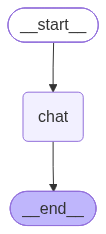

In [9]:
app

In [11]:
# Create a new thread id for this conversation
config = {'configurable': {'thred_id':'1'}}

# User asks a question
initial_input = {'messages': [('user', "Explain gradient descent in very simple terms.")]}

# invoke
result = app.invoke(initial_input, config=config)

KeyError: 'thread_id'

In [ ]:
result

In [ ]:
message = result['__interrypt__'][0].value

message

In [ ]:
user_input = input(f"\nBackend message -{message} \n Approve this questioin? (y/n): ")

In [ ]:
final_result = app.invoke(
    Command(resume= {'approved':user_input}),
    config=config
)

In [ ]:
print(final_result)